In [1]:
# capstone project, week N

import numpy as np
import warnings
import matplotlib.pyplot as plt

from bayes_tools import (
    normalize, initial_bounds, validate_bounds_consistency,
    generate_next_point, ei_acquisition,
    append_observations, compute_iteration_diagnostics,
    fit_gp, get_length_scales, loo_predictions,
    compare_xi_proposals, print_xi_comparison,
    backtest_acquisitions, print_backtest_summary,
)
from viz_tools import (
    plot_2d_bo, plot_bo_diagnostics, plot_loo_calibration, plot_xi_sensitivity,
    plot_acquisition_backtest,
)

# Function 2

2D, exploratory phase, **using expected improvement (EI)**, so `xi` is the hyperparameter to tune here rather than UCB's `kappa`. Otherwise structured to match `function1.ipynb` (which is still on UCB/`kappa`).

**Why EI, and what the backtest can and can't tell you.** EI is chosen because this is an exploration phase and EI weighs *how much* a point might improve rather than just whether it might, trading exploration against exploitation without a hand-set weight. The backtest below does not carry that decision, in either direction -- at this sample size it cannot separate the plausible families at all.

Concretely, as of 11 points the top four configs are `ei_xi001` 0.2824, `exploit` 0.2886, `ucb_k1` 0.2900, `pi_xi001` 0.2928 -- a spread of 0.011 in mean regret, on a `y` range of 0.68, from 50 splits of 5 candidates. That's a dead heat. It is also demonstrably unstable: on the 10-point initial batch alone `ucb_k1` led and EI sat third; adding a single observation moved EI to first. Do not read the top of that table as a result.

What *is* robust across both runs is the tail: `ucb_k5` (0.339) and `max_variance` (0.362) are clearly worse, and that's structural rather than incidental. Regret is scored by picking among held-out points whose true `y` the scorer already knows, so the metric rewards whatever ranks closest to the GP posterior mean -- recognition is inherently an *exploitation* task, with no credit for reducing uncertainty. Heavy variance-weighting is therefore penalised by construction: agreement with `argmax mu` runs `exploit` 100%, `ucb_k1` 82%, `pi` 78%, `ei` 72%, `ucb_k5` 50%, `max_variance` 22%. Note EI wins on regret despite ranking *less* like `argmax mu` than three configs above it -- another sign the top of the table is noise, not signal.

Worth knowing why EI behaves the way it does here: in all 50 splits, *every* candidate's `mu` falls below the seed set's best `y`, so EI's improvement term is negative everywhere and it leans on its `sigma*phi(z)` term. EI is doing something partly variance-seeking on this data. Under this metric that's a handicap; for actually proposing a new point in an exploratory phase it's the behaviour you want.

So: treat the backtest as a weak exploitation-phase check that becomes informative later, once there are more points and the goal shifts to drilling in. It cannot test which config proposes a good *new* location, because there's no ground truth for that without a real evaluation.

Other decisions carried over:

- **Bounds respect `X >= 0`** (external info from earlier in the capstone) via `lower_limit=0.0`, plus a sanity check that the data agrees. The old version of this notebook called `initial_bounds(X, pad_fraction=1.0)` with no lower limit, which proposes bounds containing physically impossible negative inputs.
- **Initial data is loaded once and never modified**; weekly results accumulate in `new_X`/`new_y` and are combined with `append_observations`. The old version reassigned `X`/`y` directly, so there was nowhere for collected observations to live.
- **No y-scaling in this notebook.** Function 2's `y` is already roughly unit-scale (spanning about -0.066 to 0.611, std 0.225), so the `fit_y_scale`/`to_scaled_units` step function 1 needs is unnecessary here and was removed. It cost nothing to drop: `fit_gp` passes `normalize_y=True`, so the GP standardises `y` internally and its mean, std, and ARD length-scales are identical either way (verified). The only thing the rescale affected was the absolute meaning of `xi`, which is now in **raw `y`-units** -- `xi=0.01` is about 1.5% of the observed `y` spread. Revisit this if `y` later picks up an outlier that blows the range open, the way function 1's does.
- **Sensitivity check** (`get_length_scales`) and **surrogate calibration** (`loo_predictions`/`plot_loo_calibration`), same as the higher-D functions.
- **Dropped** the old "generalise to get all of them" loop over all 8 functions. It used the pre-`lower_limit` bounds, and each function now has its own notebook with its own settings.

Consistency note: EI is used *throughout* -- the proposal, the contour plot, and the diagnostics replay all pass `acquisition="ei"` with the same `XI`. Mixing families between those reconstructs acquisition values that never applied. **This currently bites the one recorded observation**: it appears to have been proposed under the old notebook's `ucb`/`kappa=5.0`, so replaying it as EI reports an acquisition value of ~1.5e-12. That number is an artefact of the mismatch, not a property of the point -- `compute_iteration_diagnostics` applies one setting to the whole history and cannot represent a mixed one.

In [2]:
X_initial = np.load("initial_data/function_2/initial_inputs.npy")
y_initial = np.load("initial_data/function_2/initial_outputs.npy")
n_initial = len(y_initial)
D = X_initial.shape[1]

# Once, at the very start of the capstone:
new_X = np.empty((0, D))
new_y = np.empty((0,))

## Update this once per week

Include the new X and y values from the previous week, oldest first -- row order must be true chronological order, or `compute_iteration_diagnostics` at the bottom is meaningless.


In [3]:
# Append last week's result BEFORE proposing this week's point, e.g.:
#
# new_X, new_y = append_observations(new_X, new_y, x_next, the_result_you_got)
# new_X = np.array([
#     [0.123456, 0.654321],
# ])
# new_y = np.array([0.4567])

new_X = np.array([[0.833607, 1.050529]])
new_y = np.array([0.028787796478021325])

print("observations collected so far:", len(new_y))

observations collected so far: 1


## Build the full dataset (initial + everything collected so far)

In [4]:
X, y = append_observations(X_initial, y_initial, new_X, new_y)

print("X_initial shape:", X_initial.shape, "| y_initial shape:", y_initial.shape)
print("new_X shape:     ", new_X.shape, "| new_y shape:     ", new_y.shape)
print("combined X shape:", X.shape, "| combined y shape:", y.shape)

print("\nX range per dimension:")
print("  min:", X.min(axis=0))
print("  max:", X.max(axis=0))
print("y range:", y.min(), "to", y.max())

# X is known to never be negative (external info from earlier in the
# capstone) -- remove lower_limit=0.0 below if that turns out not to
# apply to this particular function.
bounds = initial_bounds(X_initial, pad_fraction=1.0, lower_limit=0.0)
validate_bounds_consistency(X, bounds)
print("\nBounds:\n", bounds)

X_initial shape: (10, 2) | y_initial shape: (10,)
new_X shape:      (1, 2) | new_y shape:      (1,)
combined X shape: (11, 2) | combined y shape: (11,)

X range per dimension:
  min: [0.14269907 0.02869772]
  max: [0.87779099 1.050529  ]
y range: -0.06562362443733738 to 0.6112052157614438

Bounds:
 [[0.         1.6128829 ]
 [0.         1.82443068]]


## Backtest acquisition functions 

Make sure that we are picking the best acquisition function - test on part of the existing data set and see how closely our fn + param would match it. 
Only checking on existing data so not able to test which produces a good new point but it does give me some hints.


/Users/nic.gibson/anaconda3/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 1 of parameter k1__k2__length_scale is close to the specified upper bound 10.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/nic.gibson/anaconda3/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified upper bound 10.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/nic.gibson/anaconda3/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-06. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/nic.gibson/anaconda3/lib/python3.1

      config |  mean regret |  median regret |  mean picked y
-------------------------------------------------------------
    ei_xi001 |       0.2824 |          0.268 |         0.2475
     exploit |       0.2886 |         0.3137 |         0.2413
      ucb_k1 |         0.29 |         0.2906 |         0.2399
    pi_xi001 |       0.2928 |         0.2906 |         0.2371
      ucb_k5 |       0.3386 |         0.3418 |         0.1913
     max_var |       0.3624 |         0.3742 |         0.1675


/Users/nic.gibson/anaconda3/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified lower bound 0.01. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/nic.gibson/anaconda3/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 1 of parameter k1__k2__length_scale is close to the specified upper bound 10.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/nic.gibson/anaconda3/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-06. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/nic.gibson/anaconda3/lib/python3.1

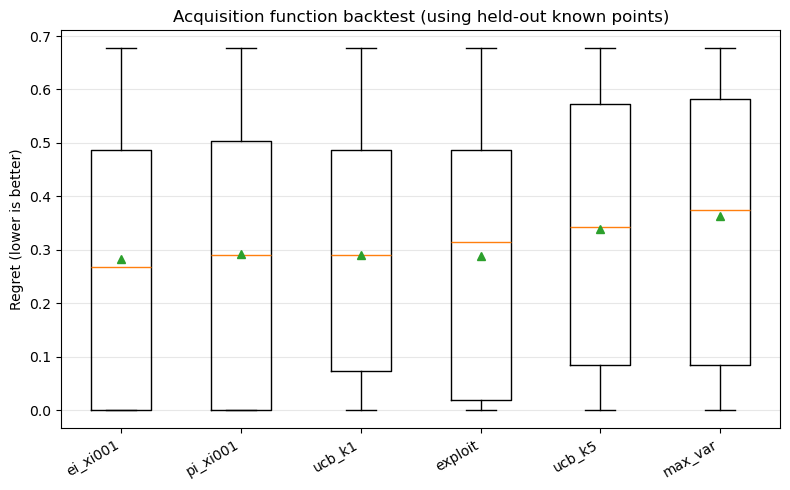

In [5]:
# xi is in raw y-units here (no y-scaling in this notebook -- see header).
# One EI row only: sweeping xi is uninformative under this metric.
backtest_configs = [
    {"name": "ei_xi001", "acquisition": "ei",  "xi": 0.01},
    {"name": "pi_xi001", "acquisition": "pi",  "xi": 0.01},
    {"name": "ucb_k1",   "acquisition": "ucb", "kappa": 1.0},
    {"name": "ucb_k5",   "acquisition": "ucb", "kappa": 5.0},
    {"name": "exploit",  "acquisition": "exploit"},
    {"name": "max_var",  "acquisition": "max_variance"},
]

backtest_results = backtest_acquisitions(
    X, y, bounds, backtest_configs,
    n_repeats=50, seed_frac=0.5, maximize=True,
    gp_kwargs={"n_restarts_optimizer": 15}, random_state=0,
)
print_backtest_summary(backtest_results)

fig = plot_acquisition_backtest(backtest_results)
plt.show()

## Sensitivity check: which dimension matters more right now

Cheap to check even in 2D -- worth knowing before staring at the contour plot. A length-scale pinned at the upper `length_scale_bounds` means the GP thinks that axis is close to irrelevant; only trust "pinned vs. not pinned", not the relative size of two pinned dimensions.

In [6]:
gp_check = fit_gp(X, y, bounds, n_restarts_optimizer=20, random_state=0)
length_scales = get_length_scales(gp_check)
for dim, ls in sorted(enumerate(length_scales), key=lambda t: t[1]):
    tag = "(most sensitive)" if ls == length_scales.min() else ("(least sensitive)" if ls == length_scales.max() else "")
    print(f"x{dim}: length_scale = {ls:.3f} {tag}")

x0: length_scale = 0.023 (most sensitive)
x1: length_scale = 0.492 (least sensitive)


/Users/nic.gibson/anaconda3/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-06. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


## Compare xi values before committing

This is the cell that actually decides `xi`. Cheap, no real evaluation spent: fits ONE shared GP and shows where each candidate `xi` would propose to search *right now*. Because the model is shared, any difference between rows is purely down to `xi`, not GP-refit noise.

`xi` is EI's improvement margin in **raw `y`-units** (no scaling in this notebook). For reference, the observed `y` spread is about 0.68, so the sweep below runs from 0 to roughly 7% of that spread.

How to read it: watch whether `x_next`/`dist_from_best` keeps changing as `xi` increases. `xi=0` asks only for any improvement at all; larger `xi` demands a more decisive one and should push the search further out. Once the proposals stop moving, a larger `xi` buys nothing.

As of 11 points the response is smooth and well-behaved -- `dist_from_best` climbs steadily (about 0.36 at `xi=0` to 0.52 at `xi=0.05`) with `pred_mean` falling and `pred_std` rising as expected, and nothing has saturated by the top of the range. So `xi` is a live dial here rather than a setting that stops mattering; if you want more exploration than the committed value gives, raising `xi` will deliver it.

Don't assume that stays true. This behaviour is data-dependent and can be non-monotone -- a larger margin can collapse EI in a far region whose `mu` is low and hand the argmax to a nearer high-variance point instead, moving the proposal *closer* to the incumbent. Read the table each week rather than reasoning from the sign of `xi`.

/Users/nic.gibson/anaconda3/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-06. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


      xi |                   x_next |  acq_value |  pred_mean |  pred_std |  dist_from_best
-------------------------------------------------------------------------------------------
       0 |            [0.689,0.569] |     0.0440 |     0.6138 |    0.1069 |          0.3581
   0.002 |            [0.689,0.565] |     0.0430 |     0.6136 |    0.1072 |          0.3614
    0.01 |            [0.69 ,0.549] |     0.0391 |     0.6127 |    0.1082 |          0.3773
   0.025 |            [0.691,0.5  ] |     0.0325 |     0.6088 |    0.1126 |          0.4265
    0.05 |            [0.694,0.404] |     0.0238 |     0.5940 |    0.1264 |          0.5223


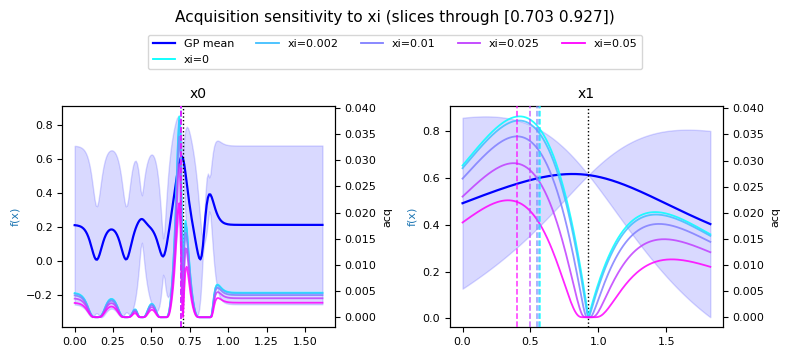


using xi = 0.01 (raw y-units, ~1.5% of observed y spread)


In [7]:
xi_rows = compare_xi_proposals(X, y, bounds, xi_values=[0.0, 0.002, 0.01, 0.025, 0.05],
                                acquisition="ei", maximize=True, n_restarts=20, random_state=0)
print_xi_comparison(xi_rows)

fig = plot_xi_sensitivity(X, y, bounds, gp_check, xi_rows, ei_acquisition, maximize=True)
plt.show()

# Committed choice, in raw y-units -- reused by the proposal, the contour plot,
# and the diagnostics replay below, so they can't silently drift apart.
# Nothing saturates across the swept range, so this is a genuine exploration
# dial: raise it to push the proposal further from the incumbent.
XI = 0.01
print(f"\nusing xi = {XI} (raw y-units, ~{100 * XI / (y.max() - y.min()):.1f}% of observed y spread)")

## Propose the next point

In [8]:
x_next, gp = generate_next_point(
    X, y, bounds,
    acquisition="ei",
    xi=XI,              # see the xi comparison above
    maximize=True,
    n_restarts=25,
    random_state=0,
)

print(f"\n--- Next point to evaluate (bounds shape {bounds.shape}) ---")
print("x_next:", np.round(x_next, 4))
print(gp.kernel_)

mu, sigma = gp.predict(normalize(x_next.reshape(1, -1), bounds), return_std=True)
print(f"GP predicted mean: {mu[0]:.4g}, predicted std: {sigma[0]:.4g}")


--- Next point to evaluate (bounds shape (2, 2)) ---
x_next: [0.6895 0.5495]
1.07**2 * Matern(length_scale=[0.0232, 0.492], nu=2.5) + WhiteKernel(noise_level=1e-06)
GP predicted mean: 0.6127, predicted std: 0.1082


/Users/nic.gibson/anaconda3/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-06. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


## Visualise the GP and acquisition function

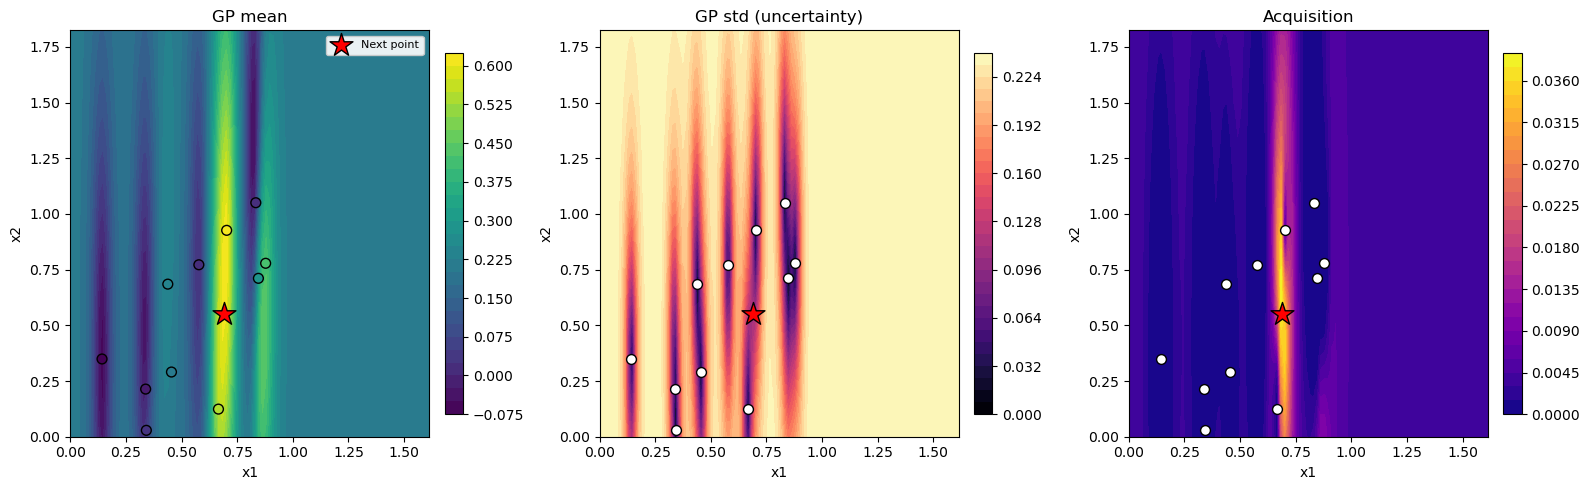

In [9]:
# ei_acquisition needs y_best explicitly (it's data, not a GP prediction).
fig = plot_2d_bo(
    X, y, bounds, gp,
    acquisition_fn=ei_acquisition,
    x_next=x_next,
    acq_kwargs={"y_best": y.max(), "xi": XI, "maximize": True},
)
plt.show()

## Sanity-check the surrogate model: leave-one-out calibration

Refits the GP once per point, leaving that point out, and predicts it from the rest. At this many points the error bars are the thing to read -- whether the true values sit inside the predicted intervals -- rather than any tight correlation.

/Users/nic.gibson/anaconda3/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-06. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/nic.gibson/anaconda3/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 1 of parameter k1__k2__length_scale is close to the specified upper bound 10.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/nic.gibson/anaconda3/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-06. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/nic.gibson/anaconda3/lib/python3.13/si

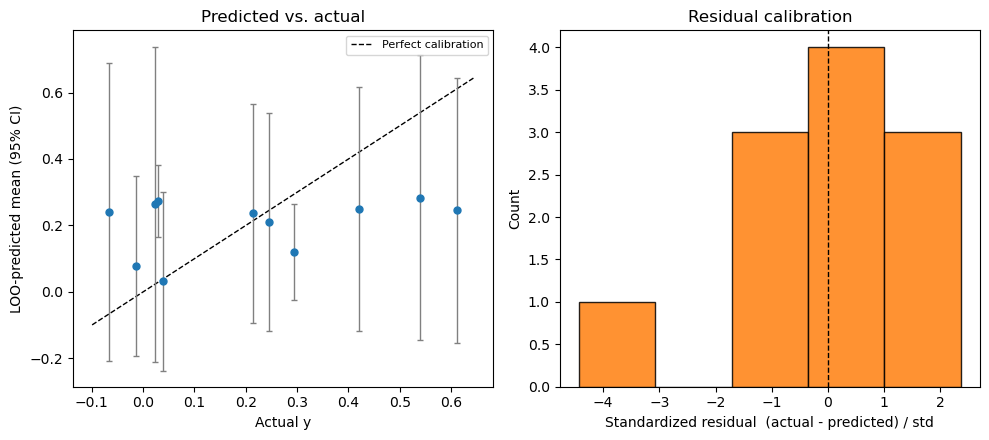

In [10]:
pred_mean, pred_std = loo_predictions(X, y, bounds, gp_kwargs={"n_restarts_optimizer": 20})
fig = plot_loo_calibration(y, pred_mean, pred_std)
plt.show()

## Iteration diagnostics

IMPORTANT: replay with the SAME acquisition settings actually used above (`ei`, `xi=XI`) -- replaying with different settings (e.g. leftover `ucb`/`kappa` from a template, or the `pi`/`xi=0.01` default) would reconstruct acquisition values that never actually applied to these proposals. This was a real bug earlier in the capstone.

Note the replay applies one setting to the entire history, so it is only faithful if every proposal in `new_X` was made with EI at this `xi`. Anything proposed under different settings will read as meaningless in the acquisition panel.

Everything here is already in raw `y`-units, so no back-conversion is needed. This needs at least one point beyond the initial batch to say anything, so it is skipped until `new_y` is non-empty.

/Users/nic.gibson/anaconda3/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 1 of parameter k1__k2__length_scale is close to the specified upper bound 10.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


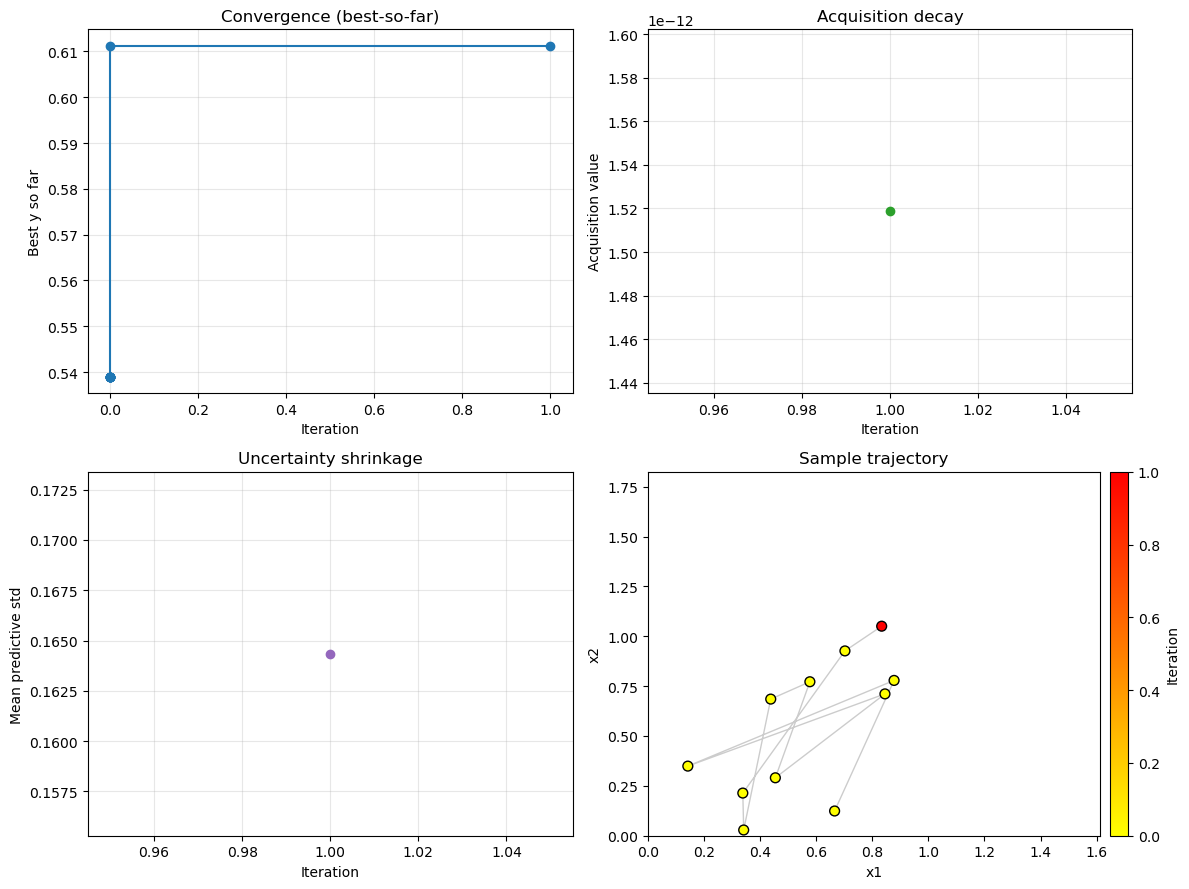

Best y so far: 0.6112052157614438


In [11]:
history = None
if len(new_y) == 0:
    print("No observations beyond the initial batch yet -- nothing to replay.")
    print("Best y so far:", y.max())
else:
    history = compute_iteration_diagnostics(X, y, bounds, n_initial=n_initial,
                                             acquisition="ei", xi=XI, maximize=True)
    fig = plot_bo_diagnostics(history, bounds)
    plt.show()

    print("Best y so far:", np.nanmax(history["y"]))

## Raw diagnostic fields

In [12]:
if history is not None:
    print("y:", history["y"])
    print("acq_value (NaN = initial batch):", history["acq_value"])

y: [ 0.53899612  0.42058624 -0.06562362  0.29399291  0.21496451  0.02310555
  0.24461934  0.03874902 -0.01385762  0.61120522  0.0287878 ]
acq_value (NaN = initial batch): [           nan            nan            nan            nan
            nan            nan            nan            nan
            nan            nan 1.51870579e-12]


In [13]:
# The proposal as a hyphen-separated string, for submission.
print("-".join(f"{v:.6f}" for v in x_next))

# Full precision as well. 6 dp is fine to submit, but paste THIS into next
# week's new_X: a 6-dp copy of function 4's proposal rounded 4e-7 outside its
# own upper bound and tripped validate_bounds_consistency.
print("\nfull precision (use for next week's new_X):")
print("-".join(repr(float(v)) for v in x_next))

0.689531-0.549497

full precision (use for next week's new_X):
0.6895306185951645-0.5494965332137313
